# kNN with cross-validation by choosing different hold-out years

In this notebook, for each pair `(pca_comp, n_nbr)`, we calculated the MAPE and R2 scores by choosing different years as holdout sets for cross validation. We printed the best combination in terms of mean MAPE and mean R2 scores over the cross-validation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from seaborn import set_style
import seaborn as sns

set_style("whitegrid")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

In [2]:
## Finds the days of a given year
def all_days_of_year(year):
    start_date = pd.Timestamp(year=year, month=1, day= 1)
    end_date = pd.Timestamp(year=year, month=12, day=31)
    return [x.strftime('%m-%d') for x in pd.date_range(start=start_date, end=end_date, freq= 'd')]

## Finds the true aggregate values of wind production per day of a given year
def true_aggregate_per_day(year):
    day_list = all_days_of_year(year)
    df_test = df[df.Year == year]
    aggregates = {}
    for day in day_list:
        df_day = df_test[df_test['MonthDay'] == day]
        aggregates[day] = sum(np.array(df_day.Wind))
    return(aggregates)

In [123]:
## chooses all different combinations in the arrays pca_comps and n_nbrs to call the other functions 
## and returns the cv_mape and cv_r2 scores for combinations 
def pca_nbr_combinations(df):
    #pca_comps = [4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45]
    #n_nbrs = [4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50]
    pca_comps = [35, 36]   ## checking small number of cases to manage runtime
    n_nbrs = [9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 50]
    comb_dic = {}   # contains list of (pca_comb, n_bdr) values
                    # format  0: (pca_comps[0], n_nbrs[0]), 1: (pca_comps[0], n_nbrs[1]) and so on
    cross_validation_mapes = []
    cross_validation_r2s = []
    cross_validation_maes = []
    preds_comb = []
    for i in range(len(pca_comps)):
        for j in range(len(n_nbrs)):
            comb_dic[len(n_nbrs)*i + j] = (pca_comps[i], n_nbrs[j])
            try:
                mapes ,r2s, mean_mae, preds = kNN_groupby_year_CV(df, pca_comps[i], n_nbrs[j])
                cross_validation_mapes.append(mapes)
                cross_validation_r2s.append(r2s)
                cross_validation_maes.append(mean_mae)
                preds_comb.append(preds)

                #displaying only the means and standard deviations across the 4 different years
                mean_mape = np.mean(mapes)
                std_mape = np.std(mapes)
                mean_r2 = np.mean(r2s)
                std_r2 = np.std(r2s) 
                print(f"Combination done {(pca_comps[i], n_nbrs[j])}: cv_mape = {mean_mape:.3f} \u00B1 {std_mape:.3f}, cv_R2 = {mean_r2:.3f} \u00B1 {std_r2:.3f}.")
            except:
                print(f"Error in combination: {(pca_comps[i], n_nbrs[j])}")
    return comb_dic, preds_comb, cross_validation_mapes, cross_validation_r2s, cross_validation_maes

## returns the cv_mape and cv_r2 scores for a particular combination of (pca_comb, n_nbr)    
def kNN_groupby_year_CV(df,pca_comp,n_nbr):   
    mapes = [0]*4
    r2s = [0]*4
    preds = []
    mean_mae = 0
    for i , test_year in enumerate([2019,2020,2021,2022]):
        true_aggregates = true_aggregate_per_day(test_year)
        pred = kNN_by_test_year(df,pca_comp, n_nbr, test_year)
        try:
            mapes[i] = mean_absolute_percentage_error(y_true= [float(x) for x in true_aggregates.values()], y_pred= pred)
            r2s[i] = r2_score(y_true= [float(x) for x in true_aggregates.values()], y_pred= pred)
            mean_mae += mean_absolute_error( y_true= [float(x) for x in true_aggregates.values()], y_pred= pred )
            preds.append(pred)
        except:
            print(f"Error in test year: {test_year}")

    return mapes , r2s, mean_mae/4, preds 

## returns the predicted values of wind power per day for test_year for a given combination (pca_comp,n_nbr)
def kNN_by_test_year(df, pca_comp, n_nbr, test_year): 
    df_train = df[df['Year'] != test_year]
    df_test = df[df['Year'] == test_year]
    features = df.columns.drop(['Unnamed: 0', 'time', 'Year', 'MonthDay', 'Wind']) #extract the features

    pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components= pca_comp))])
    pipe.fit(df_train[features])

    pca_train = pipe.transform(df_train[features])
    pca_test = pipe.transform(df_test[features])


    knn = KNeighborsRegressor(n_neighbors=n_nbr)
    knn.fit(pca_train, df_train.Wind)
    pred = knn.predict(pca_test)

    no_days = len(all_days_of_year(test_year))
    pred_per_day = [sum(pred[24*i:24*(i+1)]) for i in range(no_days)]
    return pred_per_day

In [4]:
## Finding the best combination in terms of MAPE and R2 scores and printing the errors
def find_best_combinations(cross_validation_mapes, cross_validation_r2s,comb_dic):
    cv_mapes_means = [np.mean(x) for x in cross_validation_mapes]
    cv_mapes_stds = [np.std(x) for x in cross_validation_mapes]
    cv_r2s_means = [np.mean(x) for x in cross_validation_r2s]
    cv_r2s_stds = [np.std(x) for x in cross_validation_r2s]
    best_MAPE_mean_idx = cv_mapes_means.index(min(cv_mapes_means))
    best_r2_mean_idx = cv_r2s_means.index(max(cv_r2s_means))

    print(f"Best combination in terms of mean MAPE: pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cv_mapes_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_MAPE_mean_idx]:.3f}, R2 = {cv_r2s_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_MAPE_mean_idx]:.3f} ")
    print(f"Best combination in terms of mean R2 score: pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cv_mapes_means[best_r2_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_r2_mean_idx]:.3f}, R2 = {cv_r2s_means[best_r2_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_r2_mean_idx]:.3f} ")
    return best_MAPE_mean_idx, best_r2_mean_idx

In [5]:
## Ploting for the best combinations (each for best cv_mape_mean and cv_r2_mean) for each year
def plot_best_combinations(preds_comb,best_MAPE_mean_idx, best_r2_mean_idx, cross_validation_mapes, cross_validation_r2s,comb_dic):
    fig, ax = plt.subplots(4*2, 1, figsize=(15, 8*4))
    years = {0: 2019, 1:2020, 2:2021, 3:2022}
    best_MAPE_preds = preds_comb[best_MAPE_mean_idx]
    best_r2_preds = preds_comb[best_r2_mean_idx]

    for i in range(4):
        test_year = years[i]
        days_list = all_days_of_year(test_year)
        true_aggregates = true_aggregate_per_day(test_year)
        ax[2*i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
        ax[2*i+1].plot(days_list, true_aggregates.values(), label = 'True aggregates per day') 
    
        ax[2*i].plot(days_list, best_MAPE_preds[i], label = 'Best in terms of MAPE')
        ax[2*i].set_title(f"Year: {test_year}, pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cross_validation_mapes[best_MAPE_mean_idx][i]:.3f}, R2 = {cross_validation_r2s[best_MAPE_mean_idx][i]:.3f} ")

        ax[2*i+1].plot(days_list, best_r2_preds[i], label = 'Best in terms of r2_score')
        ax[2*i+1].set_title(f"Year: {test_year}, pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cross_validation_mapes[best_r2_mean_idx][i]:.3f} R2 = {cross_validation_r2s[best_r2_mean_idx][i]:.3f}")

    for i in range(8):
        ax[i].legend(loc='lower right')
        ax[i].tick_params(axis='x', rotation = 45)
        ax[i].set_xticks([])
        ax[i].set_xlabel('Date')
        ax[i].set_ylabel('Total power per day (in MW)')

    plt.show()

In [7]:
# since wind direction is cylindrical variables, so we convert them to sine and cosine
def make_direction_to_sin_cos(df):
    new_cols = []

    for i in range(1, 40):
        dir_col = f'wind_direction_10m_{i}'
        
        sin_col = np.sin(np.deg2rad(df[dir_col]))
        cos_col = np.cos(np.deg2rad(df[dir_col]))
        
        new_cols.append(pd.DataFrame({
            f'{dir_col}_sin': sin_col,
            f'{dir_col}_cos': cos_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns=[f'wind_direction_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_without_spd_cubed = df_new.copy()  # defragment
    return df_without_spd_cubed

# Feature Engineering Trials

## Model with radius into consideration

### Extract the radius
 Use mean of all the diameters of different turbines in a farm

In [17]:
farm_name_df = pd.read_csv("../data/raw_data/hydroquebec_wind_farms_in_service.csv")
farm_names = farm_name_df.name
farm_names = [farm_names[i].replace(' wind farm', '') for i in range(len(farm_names))]

farm_details = pd.read_excel("../data/raw_data/Wind_Turbine_Database_FGP.xlsx")
farm_details = farm_details[farm_details.Province_Territory == 'Quebec']

In [18]:
## Some farms have slightly different names in these two datasets
## We manually make them the same
diff_names = ['Le Projet Éoliennes Belle-Rivière (Val-eo)', "De l'Érable", "Des Cultures (Parc Éolien)", 
              'Des Moulins I', 'Des Moulins II', 'La Dune-du-Nord aux Iles-de-la-Madeleine'
              , 'Lac Alfred', 'Le Plateau I', 'Le Plateau II',
       'Mont Louis', 'Montagne-Sèche', 'Nicolas-Riou', "Jardin d'Éole (Saint-Ulric Saint-Léandre)" 
       ]

change_name_to = ['Belle-Rivière', "De L'Érable",'Des Cultures','Des Moulins', 'Des Moulins',
 'Dune-du-Nord','Lac-Alfred','Le Plateau', 'Le Plateau 2','Mont-Louis','Montagne Sèche', 'Nicolas Riou',
 'Saint-Ulric-Saint-Léandre']

replace_map = dict(zip(diff_names, change_name_to))
farm_details['Project Name'] = farm_details['Project Name'].replace(replace_map)
result_df = farm_details.groupby('Project Name', as_index=False)['Rotor Diameter (m)'].mean()

In [19]:
print(farm_details[farm_details['Project Name'].str.contains('Seigneurie de Beaupré')]['Rotor Diameter (m)'].unique())
print(farm_details[farm_details['Project Name'].str.contains('Témiscouata')]['Rotor Diameter (m)'].unique())

[70. 82.]
[92.]


In [20]:
## These 4 farms in our original dataframe of 39 farms are only present once in the dataset that contains the diameter
## so manually setting the means to each of them having the same name from above
names = ['Seigneurie de Beaupré 2',
 'Seigneurie de Beaupré 3',
 'Seigneurie de Beaupré 4',
 'Témiscouata 2']
values = [76,76,76,92]
new_rows = pd.DataFrame({'Project Name': names, 'Rotor Diameter (m)': values})
result_df = pd.concat([result_df, new_rows], ignore_index=True)

In [21]:
farms_in_service = result_df[result_df['Project Name'].isin(farm_names)]
farms_in_service.loc[:,'name'] = farms_in_service.loc[:,'Project Name'] + ' wind farm'

C:\Users\manim\AppData\Local\Temp\ipykernel_13444\820714010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  farms_in_service.loc[:,'name'] = farms_in_service.loc[:,'Project Name'] + ' wind farm'


In [22]:
farms_in_service = farms_in_service.drop(columns=['Project Name'])
radius_df = pd.merge(farm_name_df, farms_in_service, on= ['name'])
radius_df['radius'] = radius_df['Rotor Diameter (m)']/2
radius_df = radius_df.drop(columns= ['Rotor Diameter (m)'])

## Use the radius information

In [ ]:
# since theoretically the wind power depends on speed cubed, so we modify the columns as well
def make_speed_cubed_df(df):
    new_cols = []

    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        cube_col = df[spd_col] ** 3
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubed': cube_col
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_speed_cubed = df_new.copy()  # defragment
    return df_speed_cubed

In [ ]:
## For each of the speed row, we modify it to speed cubed multiplied by radius squared
## We check this because Wind power is theoretically proportional to v^3 and area.
def multiply_radius_sq(df):    
    new_cols = []

    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        rad = radius_df[radius_df.labels == i]['radius'].values[0]
        spd_cubd_rad_sq = (df[spd_col] ** 3)*(rad ** 2)
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubd_rad_sq': spd_cubd_rad_sq 
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_spd_cubd_rad_sq = df_new.copy()  # defragment
    return df_spd_cubd_rad_sq


## Different feature trials

### Just wind speed

In [103]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df_trials = df.drop(columns= #[f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (5, 4): cv_mapes = 0.199 ± 0.031, cv_R2 = 0.891 ± 0.016.
Combination done (5, 5): cv_mapes = 0.198 ± 0.031, cv_R2 = 0.892 ± 0.016.
Combination done (5, 10): cv_mapes = 0.198 ± 0.030, cv_R2 = 0.893 ± 0.016.
Combination done (5, 15): cv_mapes = 0.198 ± 0.031, cv_R2 = 0.893 ± 0.017.
Combination done (6, 4): cv_mapes = 0.197 ± 0.030, cv_R2 = 0.896 ± 0.016.
Combination done (6, 5): cv_mapes = 0.196 ± 0.030, cv_R2 = 0.897 ± 0.017.
Combination done (6, 10): cv_mapes = 0.196 ± 0.031, cv_R2 = 0.898 ± 0.017.
Combination done (6, 15): cv_mapes = 0.196 ± 0.030, cv_R2 = 0.899 ± 0.017.
Combination done (7, 4): cv_mapes = 0.200 ± 0.030, cv_R2 = 0.895 ± 0.016.
Combination done (7, 5): cv_mapes = 0.200 ± 0.030, cv_R2 = 0.896 ± 0.016.
Combination done (7, 10): cv_mapes = 0.197 ± 0.030, cv_R2 = 0.899 ± 0.016.
Combination done (7, 15): cv_mapes = 0.197 ± 0.030, cv_R2 = 0.899 ± 0.016.
Combination done (10, 4): cv_mapes = 0.198 ± 0.030, cv_R2 = 0.897 ± 0.017.
Combination done (10, 5): cv_ma

### Just temperature

In [98]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df_trials = df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                #[f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (5, 4): cv_mapes = 0.819 ± 0.181, cv_R2 = 0.187 ± 0.053.
Combination done (5, 5): cv_mapes = 0.822 ± 0.187, cv_R2 = 0.193 ± 0.054.
Combination done (5, 10): cv_mapes = 0.828 ± 0.189, cv_R2 = 0.199 ± 0.050.
Combination done (5, 15): cv_mapes = 0.828 ± 0.191, cv_R2 = 0.203 ± 0.050.
Combination done (6, 4): cv_mapes = 0.803 ± 0.176, cv_R2 = 0.209 ± 0.058.
Combination done (6, 5): cv_mapes = 0.808 ± 0.184, cv_R2 = 0.214 ± 0.057.
Combination done (6, 10): cv_mapes = 0.812 ± 0.189, cv_R2 = 0.225 ± 0.054.
Combination done (6, 15): cv_mapes = 0.814 ± 0.190, cv_R2 = 0.225 ± 0.053.
Combination done (7, 4): cv_mapes = 0.788 ± 0.196, cv_R2 = 0.265 ± 0.059.
Combination done (7, 5): cv_mapes = 0.789 ± 0.198, cv_R2 = 0.269 ± 0.057.
Combination done (7, 10): cv_mapes = 0.792 ± 0.195, cv_R2 = 0.270 ± 0.053.
Combination done (7, 15): cv_mapes = 0.793 ± 0.191, cv_R2 = 0.270 ± 0.049.
Combination done (10, 4): cv_mapes = 0.782 ± 0.191, cv_R2 = 0.287 ± 0.050.
Combination done (10, 5): cv_ma

### Just humidity

In [99]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df_trials = df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)] #+
                                #[f'relative_humidity_2m_{i}' for i in range(1,40)] 
                                )
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (5, 4): cv_mapes = 0.842 ± 0.104, cv_R2 = 0.168 ± 0.020.
Combination done (5, 5): cv_mapes = 0.841 ± 0.101, cv_R2 = 0.173 ± 0.022.
Combination done (5, 10): cv_mapes = 0.848 ± 0.103, cv_R2 = 0.174 ± 0.018.
Combination done (5, 15): cv_mapes = 0.854 ± 0.105, cv_R2 = 0.171 ± 0.018.
Combination done (6, 4): cv_mapes = 0.818 ± 0.107, cv_R2 = 0.218 ± 0.009.
Combination done (6, 5): cv_mapes = 0.824 ± 0.112, cv_R2 = 0.216 ± 0.010.
Combination done (6, 10): cv_mapes = 0.832 ± 0.113, cv_R2 = 0.217 ± 0.019.
Combination done (6, 15): cv_mapes = 0.841 ± 0.116, cv_R2 = 0.216 ± 0.018.
Combination done (7, 4): cv_mapes = 0.780 ± 0.105, cv_R2 = 0.281 ± 0.023.
Combination done (7, 5): cv_mapes = 0.784 ± 0.108, cv_R2 = 0.284 ± 0.028.
Combination done (7, 10): cv_mapes = 0.796 ± 0.116, cv_R2 = 0.283 ± 0.026.
Combination done (7, 15): cv_mapes = 0.802 ± 0.116, cv_R2 = 0.282 ± 0.024.
Combination done (10, 4): cv_mapes = 0.761 ± 0.114, cv_R2 = 0.342 ± 0.027.
Combination done (10, 5): cv_ma

### Just wind direction with sin and cos

In [100]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df_trials = df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                #[f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )

comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations( make_direction_to_sin_cos(df_trials))
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (5, 4): cv_mapes = 0.476 ± 0.093, cv_R2 = 0.647 ± 0.014.
Combination done (5, 5): cv_mapes = 0.481 ± 0.096, cv_R2 = 0.644 ± 0.014.
Combination done (5, 10): cv_mapes = 0.498 ± 0.103, cv_R2 = 0.636 ± 0.017.
Combination done (5, 15): cv_mapes = 0.508 ± 0.106, cv_R2 = 0.629 ± 0.018.
Combination done (6, 4): cv_mapes = 0.493 ± 0.099, cv_R2 = 0.634 ± 0.018.
Combination done (6, 5): cv_mapes = 0.498 ± 0.101, cv_R2 = 0.635 ± 0.019.
Combination done (6, 10): cv_mapes = 0.517 ± 0.105, cv_R2 = 0.624 ± 0.021.
Combination done (6, 15): cv_mapes = 0.530 ± 0.109, cv_R2 = 0.616 ± 0.022.
Combination done (7, 4): cv_mapes = 0.496 ± 0.092, cv_R2 = 0.638 ± 0.020.
Combination done (7, 5): cv_mapes = 0.499 ± 0.094, cv_R2 = 0.638 ± 0.022.
Combination done (7, 10): cv_mapes = 0.519 ± 0.101, cv_R2 = 0.624 ± 0.021.
Combination done (7, 15): cv_mapes = 0.533 ± 0.104, cv_R2 = 0.615 ± 0.021.
Combination done (10, 4): cv_mapes = 0.516 ± 0.095, cv_R2 = 0.632 ± 0.025.
Combination done (10, 5): cv_ma

### Just wind speed combined with radius

In [124]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df = multiply_radius_sq(df)
df_trials = df.drop(columns= #[f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (35, 9): cv_mape = 0.166 ± 0.025, cv_R2 = 0.911 ± 0.015.
Combination done (35, 10): cv_mape = 0.166 ± 0.025, cv_R2 = 0.910 ± 0.015.
Combination done (35, 12): cv_mape = 0.167 ± 0.025, cv_R2 = 0.910 ± 0.015.
Combination done (35, 14): cv_mape = 0.167 ± 0.025, cv_R2 = 0.910 ± 0.014.
Combination done (35, 16): cv_mape = 0.167 ± 0.024, cv_R2 = 0.910 ± 0.015.
Combination done (35, 18): cv_mape = 0.167 ± 0.024, cv_R2 = 0.910 ± 0.015.
Combination done (35, 20): cv_mape = 0.167 ± 0.025, cv_R2 = 0.910 ± 0.015.
Combination done (35, 25): cv_mape = 0.167 ± 0.025, cv_R2 = 0.910 ± 0.015.
Combination done (35, 30): cv_mape = 0.167 ± 0.024, cv_R2 = 0.909 ± 0.015.
Combination done (35, 35): cv_mape = 0.167 ± 0.024, cv_R2 = 0.909 ± 0.016.
Combination done (35, 40): cv_mape = 0.168 ± 0.024, cv_R2 = 0.908 ± 0.016.
Combination done (35, 50): cv_mape = 0.168 ± 0.024, cv_R2 = 0.907 ± 0.016.
Combination done (36, 9): cv_mape = 0.166 ± 0.025, cv_R2 = 0.911 ± 0.015.
Combination done (36, 10): 

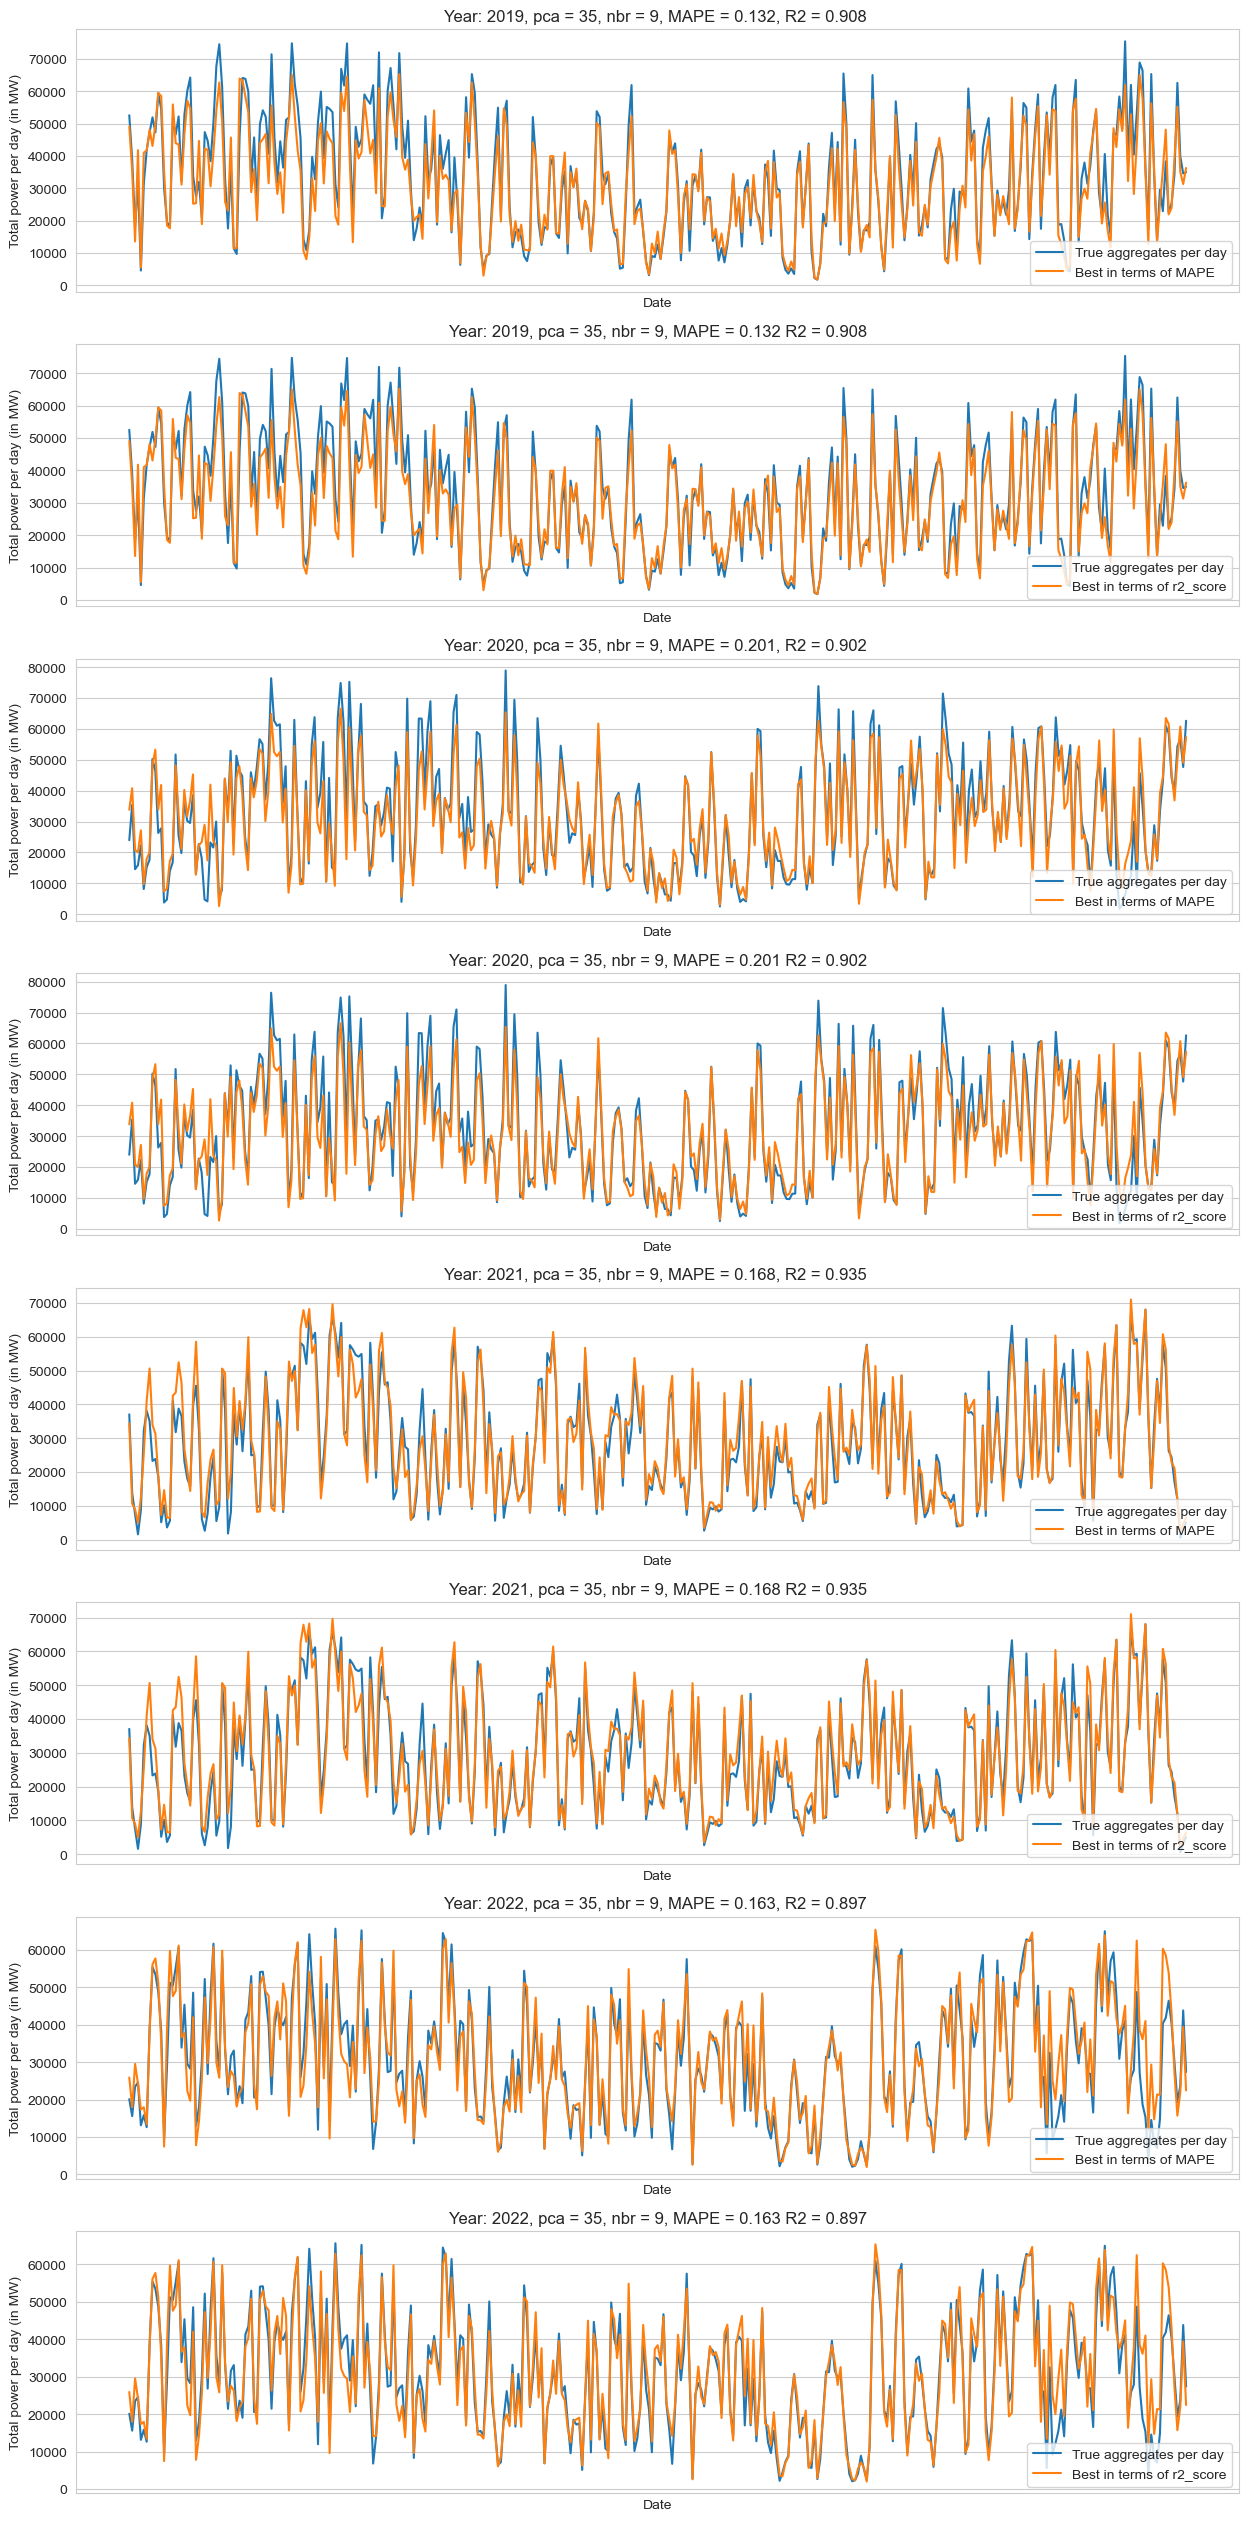

In [125]:
# Optional: Plot for each year with best combinations
plot_best_combinations(preds_comb,best_MAPE_mean_idx, best_r2_mean_idx, cv_mapes, cv_r2s, comb_dic)

### (Speed^3)*(radius^2)/(temp in Kelvin)

In [126]:
def multiply_rad_div_temp(df):    
    new_cols = []
    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        temp_col = f'temperature_2m_{i}'
        rad = radius_df[radius_df.labels == i]['radius'].values[0]
        spd_cubd_rad_sq = (df[spd_col] ** 3)*(rad ** 2)/ (df[temp_col].values + 273) #divide by temperature in Kelvin scale
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubd_rad_sq': spd_cubd_rad_sq 
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

    df_spd_cubd_rad_sq = df_new.copy()  # defragment
    return df_spd_cubd_rad_sq

In [127]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
df = multiply_rad_div_temp(df)
df_trials = df.drop(columns= #[f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)] )
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)
print('\n\n')
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Combination done (35, 9): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 10): cv_mape = 0.166 ± 0.026, cv_R2 = 0.913 ± 0.014.
Combination done (35, 12): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 14): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 16): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 18): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 20): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (35, 25): cv_mape = 0.166 ± 0.026, cv_R2 = 0.911 ± 0.014.
Combination done (35, 30): cv_mape = 0.167 ± 0.026, cv_R2 = 0.911 ± 0.015.
Combination done (35, 35): cv_mape = 0.167 ± 0.026, cv_R2 = 0.910 ± 0.015.
Combination done (35, 40): cv_mape = 0.167 ± 0.026, cv_R2 = 0.910 ± 0.015.
Combination done (35, 50): cv_mape = 0.167 ± 0.026, cv_R2 = 0.909 ± 0.015.
Combination done (36, 9): cv_mape = 0.166 ± 0.026, cv_R2 = 0.912 ± 0.014.
Combination done (36, 10): 

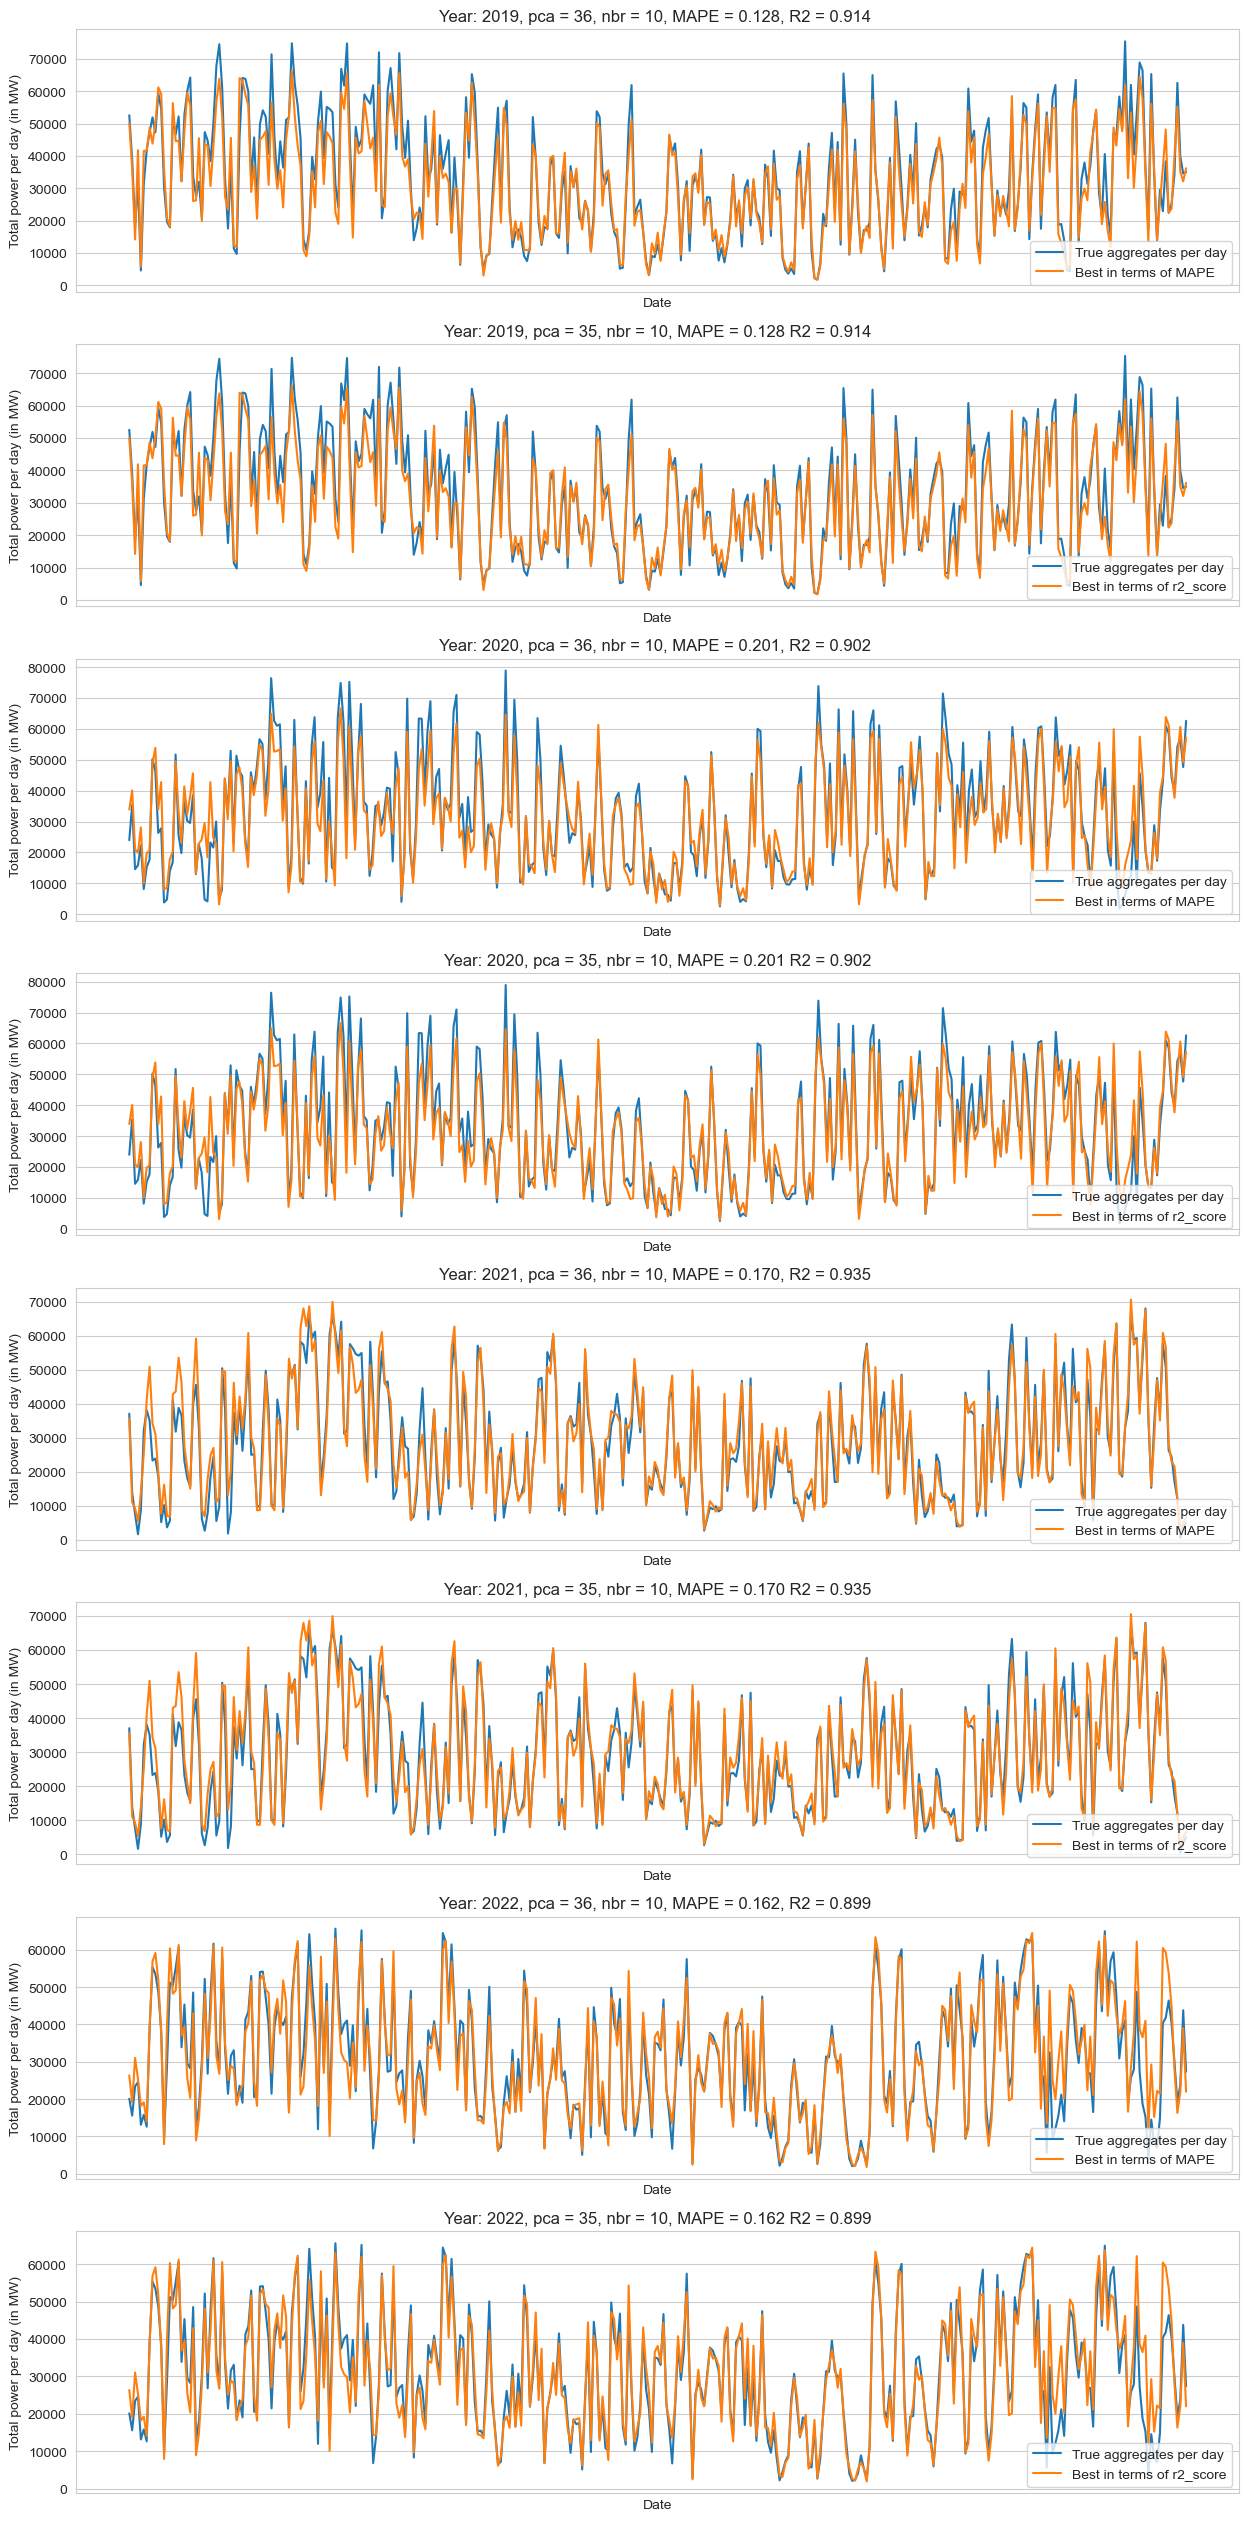

In [128]:
# Optional: Plot for each year with best combinations
plot_best_combinations(preds_comb,best_MAPE_mean_idx, best_r2_mean_idx, cv_mapes, cv_r2s, comb_dic)

## Other trials

In [92]:
def diff_trials(df):
    new_cols = []

    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        # temp_col = f'temperature_2m_{i}'
        # dir_col = f'wind_direction_10m_{i}'
        
        # sin_col = np.sin(np.deg2rad(df[dir_col]))
        # rad = radius_df[radius_df.labels == i]['radius'].values[0]
        # spd_cubd_rad_sq = (df[spd_col] ** 3)*(rad ** 2)* sin_col

        # final_col = spd_cubd_rad_sq / (df[temp_col].values + 273) #divide by temperature in Kelvin scale
        
        new_cols.append(pd.DataFrame({
            f'{spd_col}_trial': df[spd_col] 
        }))

    # Concatenate all new columns at once
    df_new = pd.concat([df.drop(columns= 
                                [f'wind_speed_10m_{i}' for i in range(1, 40)] + 
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)])] + 
                                new_cols, axis=1)

    df_final = df_new.copy()  # defragment
    return df_final
    

In [93]:
df_trials = diff_trials(df)


In [94]:
comb_dic, preds_comb, cv_mapes, cv_r2s, cv_maes = pca_nbr_combinations(df_trials)

Combination done (5, 4): cv_mapes = 0.210 ± 0.036, cv_R2 = 0.877 ± 0.027.
Combination done (5, 5): cv_mapes = 0.209 ± 0.036, cv_R2 = 0.878 ± 0.026.
Combination done (5, 10): cv_mapes = 0.208 ± 0.034, cv_R2 = 0.880 ± 0.025.
Combination done (5, 15): cv_mapes = 0.208 ± 0.034, cv_R2 = 0.881 ± 0.024.
Combination done (6, 4): cv_mapes = 0.198 ± 0.030, cv_R2 = 0.890 ± 0.020.
Combination done (6, 5): cv_mapes = 0.197 ± 0.030, cv_R2 = 0.891 ± 0.020.
Combination done (6, 10): cv_mapes = 0.196 ± 0.029, cv_R2 = 0.893 ± 0.018.
Combination done (6, 15): cv_mapes = 0.196 ± 0.030, cv_R2 = 0.893 ± 0.018.
Combination done (7, 4): cv_mapes = 0.191 ± 0.027, cv_R2 = 0.894 ± 0.018.
Combination done (7, 5): cv_mapes = 0.192 ± 0.027, cv_R2 = 0.894 ± 0.018.
Combination done (7, 10): cv_mapes = 0.191 ± 0.028, cv_R2 = 0.897 ± 0.018.
Combination done (7, 15): cv_mapes = 0.193 ± 0.029, cv_R2 = 0.897 ± 0.017.
Combination done (10, 4): cv_mapes = 0.189 ± 0.026, cv_R2 = 0.897 ± 0.017.
Combination done (10, 5): cv_ma

In [ ]:
## call find_best_combinations to see the best MAPE and R2 scores and extract the best combinations
best_MAPE_mean_idx, best_r2_mean_idx = find_best_combinations(cv_mapes, cv_r2s, comb_dic)

Best combination in terms of mean MAPE: pca = 20, nbr = 4, MAPE = 0.265 ± 0.024, R2 = 0.816 ± 0.019 
Best combination in terms of mean R2 score: pca = 10, nbr = 4, MAPE = 0.267 ± 0.031, R2 = 0.817 ± 0.027 


# Some plots to see feature importance

In [ ]:
## load the fresh data frame
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")
features_target = df.columns.drop(['Unnamed: 0', 'time', 'Year', 'MonthDay'])
df = df[features_target]

<Axes: >

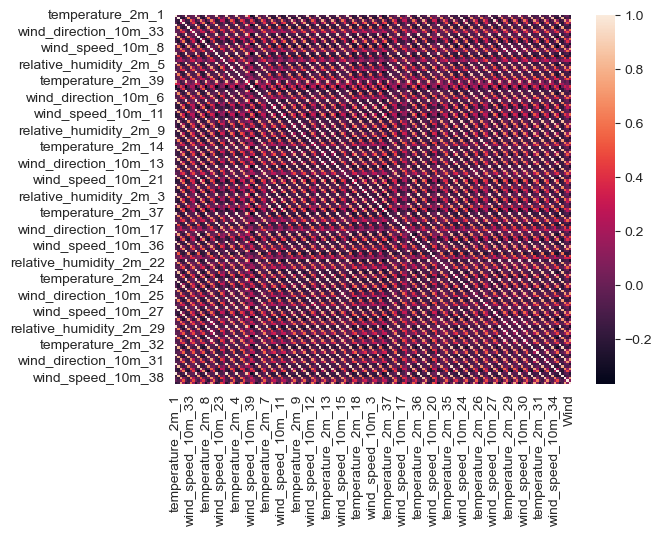

In [43]:
sns.heatmap(df.corr(), annot=False)